# **Product–Customer Matrix Notebook**
This notebook prepares the data for the **product recommendation system**.  
- Raw transactional data is transformed into a **product–customer matrix**, which shows which customers bought which products and how often.  
- This structure enables **item-based collaborative filtering** to compute product similarities and generate **personalized product recommendations**, enhancing the customer shopping experience.
If 

# **STEP 1: Creating the Product–Customer Matrix** 

The **product–customer matrix** is a crucial step to transform raw transactional data into a format suitable for a **recommendation system**.  

**Why it is needed:**  
- In the raw dataset, purchases are recorded as **individual transactions**, making it difficult to compare products or customers directly.  
- The matrix **aggregates this information**, showing:  
  - **Rows:** Customers  
  - **Columns:** Products  
  - **Values:** Frequency or quantity of each product purchased by a customer  

**Benefits for the Recommendation System:**  
- Enables computation of **similarities between products** (item-based collaborative filtering).  
- Allows the system to **identify patterns** in customer purchase behavior.  
- Facilitates **personalized product recommendations** by analyzing which products are commonly bought together.  

In [1]:
import pandas as pd
# Loading the dataset 
df = pd.read_csv("../data/online_retail.csv")

# Build Product–Customer Matrix using quantity purchased
product_customer_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

# Preview the matrix (First 15 Customers)
product_customer_matrix.head(15)

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12352.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12353.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12354.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12355.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# **STEP 2: Item-Based Collaborative Filtering**

In this step, we create a **recommendation system** that suggests products similar to a given product.  

# **Compute Cosine Similarity Between Products**
- Products are compared based on the **customers who purchased them**.  
- If **many customers buy both products**, the products are considered **similar**.  
- Cosine similarity quantifies this similarity, ranging from **0 (no similarity) to 1 (highly similar)**.  

In [2]:
from sklearn.metrics.pairwise import cosine_similarity

# Creating a new feature called product_similarity which contains the product_customer matrix
product_similarity = cosine_similarity(product_customer_matrix.T) # cosine_similarity compares the products based on the customer purchasing pattern
# .T transposes matrix with rows (customers) and columns (products)

# Convert to DataFrame for easy lookup
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=product_customer_matrix.columns,
    columns=product_customer_matrix.columns
)

# Preview of the matrix for the first 5 rows
product_similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000000,0.000227,0.000000,0.000000,0.020530,0.000000,0.000262,0.063503,...,0.0,0.001368,0.015958,0.001770,0.0,0.002864,0.0,0.013142,0.000000,0.002594
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003534,0.004001,0.000000,0.020036,0.027947,0.900955,0.119061,0.013404,...,0.0,0.001719,0.015645,0.018056,0.0,0.015814,0.0,0.011251,0.000000,0.029797
DOLLY GIRL BEAKER,0.000000,0.003534,1.000000,0.870882,0.980596,0.006296,0.005238,0.003034,0.001765,0.412043,...,0.0,0.000043,0.002882,0.345358,0.0,0.529290,0.0,0.823822,0.000097,0.006666
I LOVE LONDON MINI BACKPACK,0.000227,0.004001,0.870882,1.000000,0.883883,0.019879,0.004113,0.004043,0.008271,0.382704,...,0.0,0.001409,0.004216,0.310396,0.0,0.474777,0.0,0.749980,0.000000,0.010393
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980596,0.883883,1.000000,0.000000,0.000000,0.000000,0.000000,0.411274,...,0.0,0.000000,0.000000,0.347445,0.0,0.534280,0.0,0.838031,0.000000,0.000000


# **Step 3: Generate Similar Product Recommendations** 

This step uses the similarity matrix to provide **personalized product recommendations**.  

**Functionality:**  
1. Takes a **product name** as input.  
2. Finds products that are **most similar** based on purchase patterns.  
3. Returns the **top N recommended products** for the user.  

In [3]:
# Creating the function to give the similar products based on the input product
def get_similar_products(product_name, top_n=5):
    # Check if product exists
    if product_name not in product_similarity_df.index:
        return f"Product '{product_name}' not found in database."

    # Get similarity scores
    similarity_scores = product_similarity_df[product_name]

    # Sort by similarity (descending) and remove the product itself
    similar_products = similarity_scores.sort_values(ascending=False)[1:top_n+1]

    return similar_products.index.tolist()

# Verifying the function with example product
get_similar_products("WHITE HANGING HEART T-LIGHT HOLDER")

['RED HANGING HEART T-LIGHT HOLDER',
 'WASHROOM METAL SIGN',
 'LAUNDRY 15C METAL SIGN',
 'GREEN VINTAGE SPOT BEAKER',
 'BLUE VINTAGE SPOT BEAKER']

# **STEP 4: Product Similarity Heatmap**

In this step, we **visualize the similarity between the top 10 most purchased products** using a heatmap.  

**What the code does:**  
1. **Selects the top 10 products** based on total purchase frequency.  
2. Extracts the **pairwise similarity values** for these products from the product similarity matrix.  
3. Uses a **heatmap** to visualize how similar each product is to the others.  

**Interpretation:**  
- Darker colors indicate **higher similarity**, meaning these products are often purchased by the same customers.  
- Lighter colors indicate **lower similarity**, meaning the products are rarely bought together.  

**Business Insight:**  
- Helps identify **complementary or related products** for cross-selling and bundling strategies.  
- Supports **targeted recommendations** and improves the e-commerce customer experience.

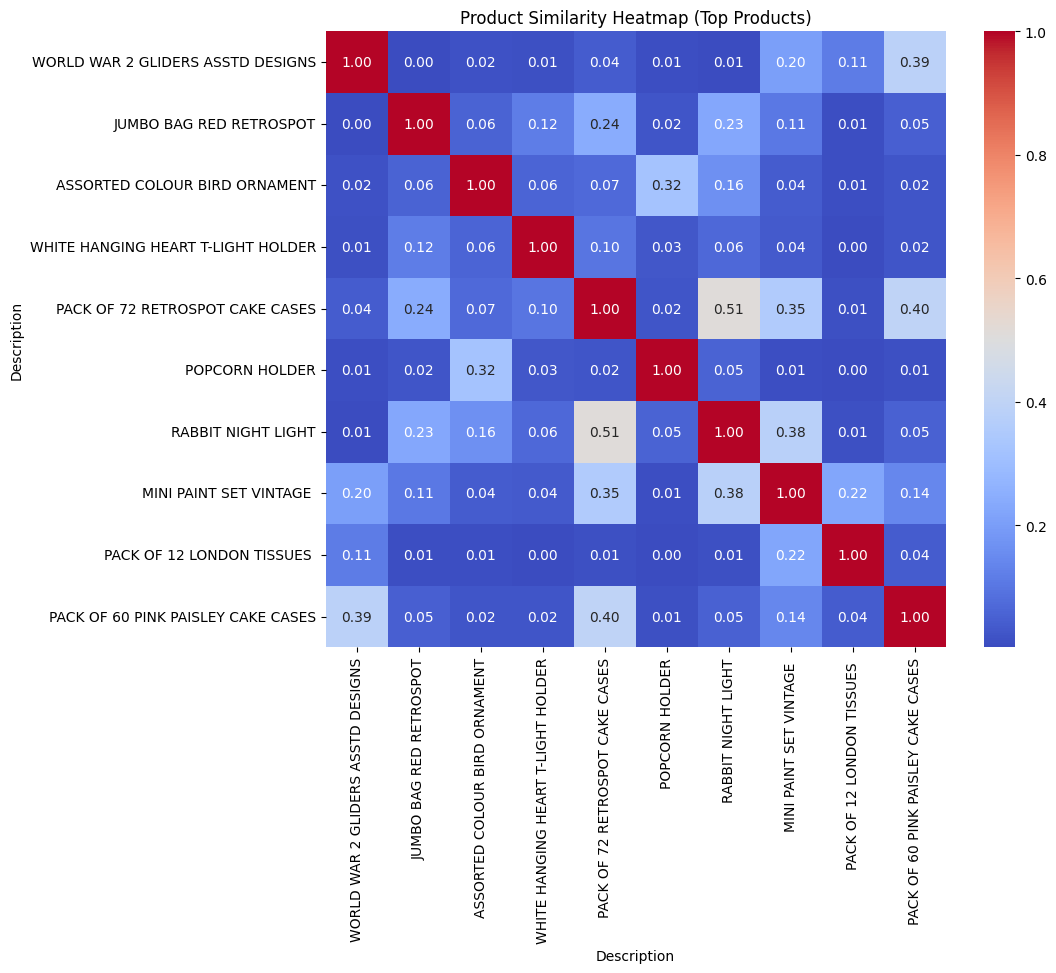

In [4]:
# Select top 10 most purchased products
top_products = (
    product_customer_matrix.sum(axis=0)
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Extract similarity for top products
top_product_similarity = product_similarity_df.loc[top_products, top_products]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(
    top_product_similarity,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Product Similarity Heatmap (Top Products)")
plt.show()

# **STEP 5: Saving the Product Similarity Matrix**

After computing the **product similarity matrix**, we save it using **pickle** so it can be reused in the recommendation system without recomputing.  

**What this code does:**  
1. Opens a file in the `models` folder to store the matrix.  
2. Serializes (`pickle.dump`) the `product_similarity_df` and saves it to disk.  
3. Prints a confirmation message once the matrix is successfully saved.  

**Business Insight:**  
- Saving the matrix allows the **recommendation system to provide instant suggestions** in real-time applications.  
- Avoids repeated computation, making the system **efficient and scalable** for production use.

In [5]:
import pickle
# We save the matrix using pickle in the models folder
with open("../models/product_similarity.pkl", "wb") as file:
    pickle.dump(product_similarity_df, file)

print('Sucessfully Saved the Matrix')

Sucessfully Saved the Matrix
